## Topic : Sampling Distributions & Standard Error

### The problem
We measure 100 people and get an average of, say, 171 cm.

Is the real city average exactly 171? Almost certainly not. We just happened to
grab those 100 people. A different 100 would have given a slightly different answer.

So how far off are we likely to be? That's what this topic answers.

In [1]:
import numpy as np
np.random.seed(4)

# Build a pretend city so we can cheat and know the real answer.
# 1 million people, true average height 170 cm, spread 10 cm.
city_heights = np.random.normal(170, 10, 1000000)
true_average = city_heights.mean()

# Now do what a real researcher does: measure just 100 people.
my_sample = np.random.choice(city_heights, size=100)

print("my sample average =", round(my_sample.mean(), 2), "cm")
print("true city average =", round(true_average, 2), "cm")
print()
print("Close, but not exact. And in real life we'd never see the second number.")

my sample average = 171.19 cm
true city average = 169.97 cm

Close, but not exact. And in real life we'd never see the second number.


### The thought experiment

Imagine we could repeat the study over and over. Each time:
measure 100 people, write down the average.

Do that 1000 times and we'd have 1000 averages. Let's see what they look like.

In [2]:
sample_averages = []                     # we'll collect one average per study

for i in range(1000):                    # run the study 1000 times
    sample = np.random.choice(city_heights, size=100)
    sample_averages.append(sample.mean())

print("the first six studies gave these averages:")
for i in range(6):
    print("  study", i + 1, "->", round(sample_averages[i], 2), "cm")

print("\nall different, all hovering around 170")

the first six studies gave these averages:
  study 1 -> 170.59 cm
  study 2 -> 170.89 cm
  study 3 -> 169.85 cm
  study 4 -> 171.65 cm
  study 5 -> 170.65 cm
  study 6 -> 169.07 cm

all different, all hovering around 170


### Three distributions — don't mix these up

This is where people get confused. There are three separate things:

1. **The population distribution** — every height in the city. Any shape.
2. **Your sample's distribution** — the 100 heights you measured.
3. **The sampling distribution** — the 1000 *averages* from above. ← the new one

That third one is the tricky one. Its data points aren't people, they're
*whole studies' averages*. Nobody's individual height appears in it.

Let's plot it.

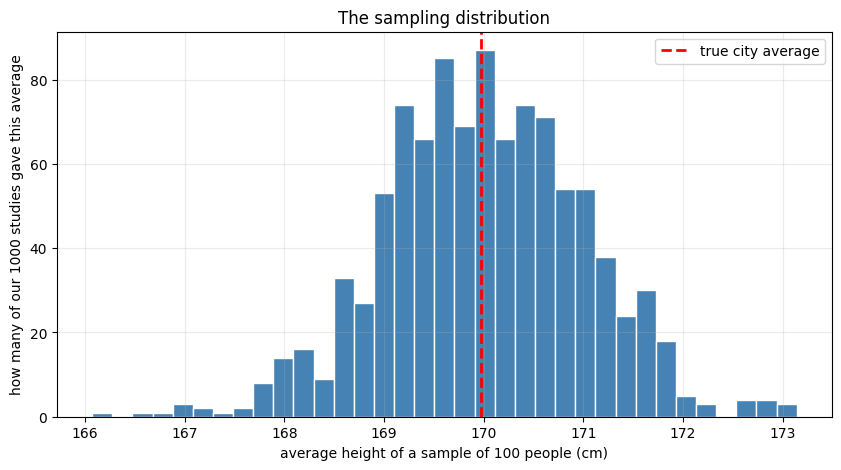

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(sample_averages, bins=35, color="steelblue", edgecolor="white")
plt.axvline(true_average, color="red", linestyle="--", linewidth=2,
            label="true city average")
plt.xlabel("average height of a sample of 100 people (cm)")
plt.ylabel("how many of our 1000 studies gave this average")
plt.title("The sampling distribution")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Three things to notice:

1. **It's a bell curve.** That's the Central Limit Theorem — averages always
   come out bell shaped.
2. **It's centred on the true average.** Our estimates scatter *around* the
   truth, not off to one side.
3. **It's much narrower than the population.** Individual people range from
   about 160 to 180 cm, but the *averages* barely leave 167–173. Tall and short
   people cancel out when you average them.



In [7]:
print("spread of our 1000 sample averages =", round(np.std(sample_averages), 3))
print("(this IS the standard error)")

spread of our 1000 sample averages = 1.005
(this IS the standard error)


### The formula, and the one thing worth remembering

    standard error = s / sqrt(n)

where s is the standard deviation of the data and n is the sample size.

Bigger sample means smaller error — no surprise. But look at the **square root**.
That's the important bit.

In [8]:
population_std = 10           # the spread of individual heights

print("sample size | standard error")
for n in [25, 100, 400, 1600]:
    standard_error = population_std / (n ** 0.5)
    print("      ", n, "   |  ", round(standard_error, 3))

sample size | standard error
       25    |   2.0
       100    |   1.0
       400    |   0.5
       1600    |   0.25


To halve the error you need **4 times** the data. To make it 10x better you
need **100 times** the data.

That's diminishing returns. Going 25 -> 100 samples halves the error and is
clearly worth it. Going 400 -> 1600 also halves it, but costs 1200 extra data
points for the same gain.

This is why opinion polls survey about 1000 people and stop. Surveying 10,000
would only be ~3x more accurate for 10x the cost.

### But wait - in real life we only have ONE sample
The definition of standard error needs 1000 studies. We only ran one.

That's exactly what the formula is for: it gets us the same answer from a
single sample. We use our own sample's standard deviation as a stand-in.

In [9]:
# real life: we have ONE sample and nothing else
s = np.std(my_sample, ddof=1)         # ddof=1 is the sample version
standard_error = s / (100 ** 0.5)

print("our one sample:")
print("  average          =", round(my_sample.mean(), 2))
print("  standard dev (s) =", round(s, 2))
print("  standard error   =", round(standard_error, 3))
print()
print("compare to the 1000-study answer:", round(np.std(sample_averages), 3))
print()
print("Almost identical - and we got it from ONE sample.")

# That's the real payoff of this topic. **One study tells you how much a study wobbles.**
# We never needed the other 999.

our one sample:
  average          = 171.19
  standard dev (s) = 10.27
  standard error   = 1.027

compare to the 1000-study answer: 1.005

Almost identical - and we got it from ONE sample.



## Topic: Confidence Intervals

### Point estimate vs interval estimate

- **Point estimate:** "the average is 171.2 cm" - a single number, no sense of reliability
- **Interval estimate:** "I'm 95% confident it's between 169.2 and 173.2 cm"

The second is more honest. It says "here's my guess, and here's how far off I might be."

### How to build one

    interval = sample mean  +/-  (multiplier x standard error)

| confidence | multiplier |
|---|---|
| 90% | 1.64 |
| 95% | 1.96 |
| 99% | 2.58 |

Higher confidence needs a **wider** interval. You trade precision for certainty.

In [11]:
sample_mean = my_sample.mean()

print("our estimate:", round(sample_mean, 2), "cm")
print()
print("confidence | interval")
for confidence, multiplier in [(90, 1.64), (95, 1.96), (99, 2.58)]:
    low  = sample_mean - multiplier * standard_error
    high = sample_mean + multiplier * standard_error
    print("   ", confidence, "%   |", round(low, 2), "to", round(high, 2))

print()
print("More confidence = wider range. Can't have both.")

our estimate: 171.19 cm

confidence | interval
    90 %   | 169.5 to 172.87
    95 %   | 169.18 to 173.2
    99 %   | 168.54 to 173.84

More confidence = wider range. Can't have both.


### An easy trap: this is NOT where 95% of people are

The confidence interval is about **where the average is**, not where individuals fall.
Those are very different ranges.

- to locate the **average** -> use the **standard error** (divide by sqrt(n))
- to describe where **individuals** fall -> use **s** (don't divide)

In [12]:
low_ci   = sample_mean - 1.96 * standard_error
high_ci  = sample_mean + 1.96 * standard_error

low_people  = sample_mean - 1.96 * s
high_people = sample_mean + 1.96 * s

print("A) interval for the AVERAGE  :", round(low_ci, 1), "to", round(high_ci, 1))
print("B) range holding 95% of PEOPLE:", round(low_people, 1), "to", round(high_people, 1))
print()

# check against the real city
in_a = np.mean((city_heights > low_ci) & (city_heights < high_ci)) * 100
in_b = np.mean((city_heights > low_people) & (city_heights < high_people)) * 100

print("what % of real people fall inside each range?")
print("  range A:", round(in_a, 1), "%   <- nowhere near 95")
print("  range B:", round(in_b, 1), "%   <- this is the 95% one")

A) interval for the AVERAGE  : 169.2 to 173.2
B) range holding 95% of PEOPLE: 151.1 to 191.3

what % of real people fall inside each range?
  range A: 15.8 %   <- nowhere near 95
  range B: 95.4 %   <- this is the 95% one


Only about 16% of people fall inside the confidence interval. It was never
meant to cover people — it's a statement about one number, the average.

### So what does "95% confident" actually mean?

It's a property of the **method**, not of your one interval:

> If you repeated the study many times, each building its own interval,
> about 95% of those intervals would contain the true value.

Let's actually check that by running the study 100 times.

In [15]:
lows = []
highs = []
means = []
did_it_catch = []

for i in range(100):                        # run the study 100 times
    sample = np.random.choice(city_heights, size=100)
    m = sample.mean()
    se = np.std(sample, ddof=1) / (100 ** 0.5)
    low = m - 1.96 * se
    high = m + 1.96 * se

    lows.append(low)
    highs.append(high)
    means.append(m)
    did_it_catch.append(low <= true_average <= high)   # True or False

number_caught = 0
for caught in did_it_catch:
    if caught == True:
        number_caught = number_caught + 1

print("out of 100 studies,", number_caught, "intervals contained the true average")
print("that's the 95% (give or take randomness)")

out of 100 studies, 96 intervals contained the true average
that's the 95% (give or take randomness)


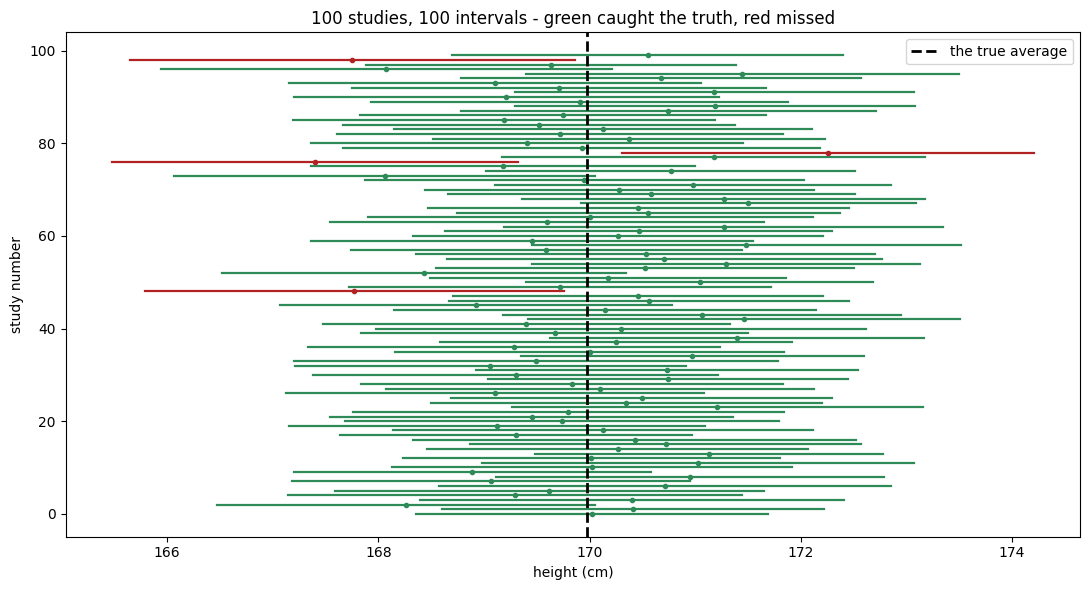

In [16]:
plt.figure(figsize=(11, 6))

for i in range(100):
    if did_it_catch[i] == True:
        colour = "seagreen"
    else:
        colour = "firebrick"
    plt.plot([lows[i], highs[i]], [i, i], color=colour, linewidth=1.6)
    plt.plot(means[i], i, "o", color=colour, markersize=3)

plt.axvline(true_average, color="black", linestyle="--", linewidth=2,
            label="the true average")
plt.xlabel("height (cm)")
plt.ylabel("study number")
plt.title("100 studies, 100 intervals - green caught the truth, red missed")
plt.legend()
plt.tight_layout()
plt.show()

Look at the picture. Every study built a **different** interval. Most (green)
crossed the black line. A few (red) missed completely.

That's what 95% confidence means: use this method repeatedly and about 95% of
the intervals will catch the truth.

### And here's the humbling part

In real life you run the study **once**. You get one interval. It either contains
the truth or it doesn't — and **you can never tell which**.

The red intervals came from perfectly correct methodology. The researcher who
produced one would have no idea they'd missed.

### Three things a confidence interval does NOT mean

**Not:** "95% of the data falls in this range."
That's mean +/- 2s, a much wider range (we saw it above).

**Not:** "95% of future sample means will land in *my* interval."
Each future study builds its *own* interval. The guarantee is about those
intervals catching the truth, not about future means landing in yours.
If your interval happened to be off-centre, this number can be way below 95%.

**Not quite:** "there's a 95% probability the truth is in my interval."
The truth is a fixed number - it's either in there or it isn't. What's random
is *which interval you happened to get*. People say this loosely all the time
and it's mostly harmless, but the guarantee is really about the method.

## Putting it to work: comparing two ML models

### The mental shift
Your test accuracy is a **sample statistic**, just like the city height average.

You have 500 test images and your model gets 87% right. But those 500 images are
only a *sample* of every image your model will ever see. A different 500 would
give a slightly different number.

So 87% isn't the truth. It's an estimate — and it has a standard error.

### A worked example

Two models, tested on the same 500 images:

| | accuracy | 95% interval |
|---|---|---|
| Model A | 87.2% | 84.3% to 90.1% |
| Model B | 87.4% | 84.5% to 90.3% |

The gap between the models is **0.2%**. The uncertainty in each is **±2.9%**.

The uncertainty is roughly 15 times bigger than the difference. Those intervals
sit almost on top of each other — A's true accuracy could be 89% while B's is
85%, the exact opposite of what we measured.

**Verdict: we have not shown B is better.** We've shown that with 500 test
images we can't tell them apart.

Now compare that to a real difference:

| | accuracy | 95% interval |
|---|---|---|
| Model A | 80.0% | 76.5% to 83.5% |
| Model B | 90.0% | 87.4% to 92.6% |

No overlap at all. B's worst case (87.4%) still beats A's best case (83.5%).
**This** is a genuine improvement — the gap survives the uncertainty.

### The rule you can actually use

    intervals overlap a lot   -> the difference is noise
    intervals don't overlap   -> the difference is real
    intervals barely touch    -> inconclusive, get more data

You compare **intervals**, not points.

### What the width of an interval means (easy to get wrong)

Interval width is about **how much test data you used**, not about how good your
model is. Same model, different test set sizes:

| test set size | interval |
|---|---|
| 100 | 85% ± 7.00% |
| 500 | 85% ± 3.13% |
| 5,000 | 85% ± 0.99% |
| 50,000 | 85% ± 0.31% |

The model is identical in every row. Only the measurement got more careful.

So a wide interval means "I didn't test on enough data" — it says nothing about
model quality. Want a narrower interval? Use a bigger test set.

(Also worth knowing: with a fixed test set, higher accuracy automatically gives
a *narrower* interval. Uncertainty is largest near 50% accuracy — maximum
coin-flipping — and shrinks as you approach 100%.)

### Why this habit matters

Without it, here's what happens. You tweak a hyperparameter, accuracy goes from
87.2% to 87.4%, you conclude the tweak worked, you keep it, you move on.

But you just measured **noise**. Re-run with a different random seed and it
might reverse.

Do that a dozen times and you've built a model full of changes that do nothing —
while believing you've been steadily improving it. That's the self-deception
this prevents.

### The one thing to remember

A bare accuracy number is not enough. Every number needs its uncertainty
attached, and you compare ranges, not points.

Worth knowing: most tutorials and plenty of published papers report accuracy as
a bare number with no interval. Asking "but what's the uncertainty?" genuinely
puts you ahead of a lot of practitioners.